Código adaptado de:

[1] Aurélien Géron, Hands-On Machine Learning with Scikit-Learn: Concepts, Tools and Techniques to Build Intelligent Systems, Keras & tensorFlow, Third Edition, O'Reilly, 2023.

# Tarefa

1. Replique o experimeto com o conjunto de dados `MNIST` do Pytorch:
    ``` python
    train_full  = datasets.MNIST(root="data", train=True, download=True)     # carrega conjunto de treinamento
    test_ds     = datasets.MNIST(root="data", train=False, download=True)    # carrega conjunto de teste
    ```

  e os seguintes Autoencoders: convolucional, esparso e por remoção de ruído. Para cada modelo teste 3 valores distintos para a dimensionalidade do espaço latente.

- Capture a perda (MSE) por época.
- Mostre as reconstruções

**Entregáveis**:
1. Notebook `.ipynb`.
2. Relatório `.pdf`:
    - Reporte e comente os resultados no relatório.
    - Incluir gráficos gerados.

# Bibliotecas

In [1]:
! pip install torchinfo

In [2]:
import sys                                                  # importa acesso a informações do sistema
import os                                                   # importa utilidades de sistema de arquivos
import numpy as np                                          # importa Numpy
import torch                                                # importa PyTorch
import torch.nn as nn                                       # importa módulos de redes neurais
import torch.optim as optim                                 # importa otimizadores
from torch.utils.data import DataLoader, TensorDataset      # importa utilitários de dados
from torchvision import datasets                            # importa datasets
from torchinfo import summary                               # importa função para exibir resumo das arquiteturas de rede
import matplotlib.pyplot as plt                             # importa biblioteca de gráficos
import matplotlib as mpl                                    # importa configurações avançadas de gráficos Matplotlib
from scipy.spatial.transform import Rotation                # importa rotação 3D para gerar dados sintéticos
from tqdm.auto import tqdm                                  # importa tqdm adaptável (funciona em terminal e notebook)
torch.manual_seed(42)                                       # fixa semente do PyTorch para reprodutibilidade
np.random.seed(42)                                          # fixa semente do NumPy para reprodutibilidade

# Hiperparâmetros

In [3]:
Z_DIM = 2
Z_DIM_DENOISING_AE = 30
Z_DIM_SPARSE_AE = 300
N_EPOCHS = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # escolhe GPU se disponível

## Dados

In [4]:
# Carregar MNIST
train_full  = datasets.MNIST(root="data", train=True, download=True)     # carrega conjunto de treinamento
test_ds     = datasets.MNIST(root="data", train=False, download=True)    # carrega conjunto de teste
X_full = train_full.data.float() / 255.0                                        # normaliza imagens de treinamento
y_full = train_full.targets.long()                                              # rótulos de treinamento
X_test = test_ds.data.float() / 255.0                                           # normaliza imagens de teste
y_test = test_ds.targets.long()                                                 # rótulos de teste

X_train = X_full[:-5000]  # fatia X treinamento
y_train = y_full[:-5000]  # fatia y rótulos
X_valid = X_full[-5000:]  # fatia X validação
y_valid = y_full[-5000:]  # fatia y rótulos

X_train = X_train.unsqueeze(1)      # adiciona canal para shape [batch, channels, height, width] (ou (B, C, H, W))
X_valid = X_valid.unsqueeze(1)      # adiciona canal para shape [batch, channels, height, width] (ou (B, C, H, W))
X_test  = X_test.unsqueeze(1)       # adiciona canal para shape [batch, channels, height, width] (ou (B, C, H, W))

train_ds = TensorDataset(X_train, X_train)                      # conjunto de treinamento
valid_ds = TensorDataset(X_valid, X_valid)                      # conjunto de validação
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)   # dataloader de treinamento
valid_dl = DataLoader(valid_ds, batch_size=256, shuffle=False)  # dataloader de validação

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.85MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 297kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.99MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 653kB/s]


In [5]:
train_dl_conv = DataLoader(train_ds, batch_size=128, shuffle=True)      # conjunto de treinamento
valid_dl_conv = DataLoader(valid_ds, batch_size=256, shuffle=False)     #  conjunto de validação

# Autoencoders profundos (convolutionais)

## Rede Neural

In [6]:
# codificador convolucional
class ConvEncoder(nn.Module):
    def __init__(self):                                 # construtor
        super().__init__()                              # base
        self.net = nn.Sequential(                       # sequência de camadas
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, Z_DIM, kernel_size=3, padding=1),
            nn.AdaptiveAvgPool2d((1, 1)),               # global average pooling
        )
    def forward(self, x):           # forward
        x = self.net(x)             # aplica camadas
        z = x.view(x.size(0), -1)
        return z                    # retorna código

# decodificador convolucional
class ConvDecoder(nn.Module):
    def __init__(self):                             # construtor
        super().__init__()                          # base
        self.fc = nn.Linear(Z_DIM, 3 * 3 * 16)
        self.net = nn.Sequential(                   # sequência de camadas
            nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
        )
    def forward(self, z):           # forward
        x = self.fc(z)              # projeta para mapa baixo
        x = x.view(-1, 16, 3, 3)
        x = self.net(x)             # aplica deconvs
        x = x.squeeze(1)            # remove canal para (N,28,28)
        return x                    # retorna reconstrução

# AE convolucional
class ConvAE(nn.Module):
    def __init__(self):                 # construtor
        super().__init__()              # base
        self.encoder = ConvEncoder()    # instancia encoder
        self.decoder = ConvDecoder()    # instancia decoder
    def forward(self, x):               # forward
        z = self.encoder(x)             # codifica
        x_hat = self.decoder(z)         # decodifica
        return x_hat, z                 # retorna reconstrução e código

conv_ae = ConvAE().to(device)  # instancia ConvAE

In [7]:
# Inspecionar
summary(conv_ae, input_size=(1, 1, 28, 28), col_names=("input_size", "output_size", "num_params"))  # mostra resumo do AE conv

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ConvAE                                   [1, 1, 28, 28]            [1, 28, 28]               --
├─ConvEncoder: 1-1                       [1, 1, 28, 28]            [1, 2]                    --
│    └─Sequential: 2-1                   [1, 1, 28, 28]            [1, 2, 1, 1]              --
│    │    └─Conv2d: 3-1                  [1, 1, 28, 28]            [1, 16, 28, 28]           160
│    │    └─ReLU: 3-2                    [1, 16, 28, 28]           [1, 16, 28, 28]           --
│    │    └─MaxPool2d: 3-3               [1, 16, 28, 28]           [1, 16, 14, 14]           --
│    │    └─Conv2d: 3-4                  [1, 16, 14, 14]           [1, 32, 14, 14]           4,640
│    │    └─ReLU: 3-5                    [1, 32, 14, 14]           [1, 32, 14, 14]           --
│    │    └─MaxPool2d: 3-6               [1, 32, 14, 14]           [1, 32, 7, 7]             --
│    │    └─Conv2d: 3-7        

In [8]:
# Inspecionar
summary(conv_ae.encoder, input_size=(1, 1, 28, 28), col_names=("input_size", "output_size", "num_params"))  # mostra resumo do encoder conv

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ConvEncoder                              [1, 1, 28, 28]            [1, 2]                    --
├─Sequential: 1-1                        [1, 1, 28, 28]            [1, 2, 1, 1]              --
│    └─Conv2d: 2-1                       [1, 1, 28, 28]            [1, 16, 28, 28]           160
│    └─ReLU: 2-2                         [1, 16, 28, 28]           [1, 16, 28, 28]           --
│    └─MaxPool2d: 2-3                    [1, 16, 28, 28]           [1, 16, 14, 14]           --
│    └─Conv2d: 2-4                       [1, 16, 14, 14]           [1, 32, 14, 14]           4,640
│    └─ReLU: 2-5                         [1, 32, 14, 14]           [1, 32, 14, 14]           --
│    └─MaxPool2d: 2-6                    [1, 32, 14, 14]           [1, 32, 7, 7]             --
│    └─Conv2d: 2-7                       [1, 32, 7, 7]             [1, 64, 7, 7]             18,496
│    └─ReLU: 2-8           

In [9]:
# Inspecionar
summary(conv_ae.decoder, input_size=(1, Z_DIM), col_names=("input_size", "output_size", "num_params"))  # mostra resumo do decoder conv

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ConvDecoder                              [1, 2]                    [1, 28, 28]               --
├─Linear: 1-1                            [1, 2]                    [1, 144]                  432
├─Sequential: 1-2                        [1, 16, 3, 3]             [1, 1, 28, 28]            --
│    └─ConvTranspose2d: 2-1              [1, 16, 3, 3]             [1, 32, 7, 7]             4,640
│    └─ReLU: 2-2                         [1, 32, 7, 7]             [1, 32, 7, 7]             --
│    └─ConvTranspose2d: 2-3              [1, 32, 7, 7]             [1, 16, 14, 14]           4,624
│    └─ReLU: 2-4                         [1, 16, 14, 14]           [1, 16, 14, 14]           --
│    └─ConvTranspose2d: 2-5              [1, 16, 14, 14]           [1, 1, 28, 28]            145
Total params: 9,841
Trainable params: 9,841
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.25
Input size (MB)

## Treinamento

In [10]:
criterion = nn.MSELoss()                                    # define perda MSE
optimizer = optim.NAdam(conv_ae.parameters(), lr=0.002)     # define otimizador

In [11]:
# Loop de treinamento
def treinar_ae(model, train_dl, valid_dl, optimizer, criterion, epochs=100, l1_regularization=False, lambda_l1=1e-4, device=device):

    train_hist = []                             # histórico treinamento
    valid_hist = []                             # histórico validação

    progress_bar = tqdm(range(epochs), desc="Época", ncols=100)

    # ---------------------- TREINAMENTO ----------------------
    for _ in progress_bar:                      # itera épocas
        model.train()                           # modo treinamento
        running, n = 0.0, 0                     # acumuladores
        for xb, yb in train_dl:                 # itera lotes de treinamento
            xb = xb.to(device)                  # move entrada
            yb = yb.squeeze(1).to(device)       # remove canal para shape (N,28,28)
            optimizer.zero_grad()               # zera gradientes
            x_hat, z = model(xb)                # forward

            # calcula perda
            if l1_regularization:
                loss = criterion(x_hat, yb) + lambda_l1 * z.abs().mean()
            else:
                loss = criterion(x_hat, yb)

            loss.backward()                     # retropropaga
            optimizer.step()                    # atualiza
            running += loss.item() * xb.size(0) # acumula perda
            n += xb.size(0)                     # acumula amostras
        train_loss = running / n
        train_hist.append(train_loss)           # guarda perda média

        # ---------------------- VALIDAÇÃO ----------------------
        model.eval()                                # modo avaliação
        with torch.no_grad():                       # sem gradientes
            running, n = 0.0, 0                     # zera acumuladores
            for xb, yb in valid_dl:                 # itera lotes de validação
                xb = xb.to(device)                  # move entrada
                yb = yb.squeeze(1).to(device)       # remove canal
                x_hat, _ = model(xb)                # forward
                loss = criterion(x_hat, yb)         # perda
                running += loss.item() * xb.size(0) # acumula
                n += xb.size(0)                     # acumula
            valid_loss = running / n
            valid_hist.append(valid_loss)           # guarda perda média

        progress_bar.set_postfix({
            "Treino": f"{train_loss:.4f}",
            "Val": f"{valid_loss:.4f}"
        })

    return train_hist, valid_hist

In [12]:
def curvas_de_treinamento(train_hist, valid_hist):
    plt.figure(figsize=(5,3))                   # cria figura
    plt.plot(train_hist, label="treinamento")   # plota perda de treino
    plt.plot(valid_hist, label="validação")     # plota perda de validação
    plt.xlabel("Época")                         # rótulo eixo x
    plt.ylabel("MSE")                           # rótulo eixo y
    plt.legend()                                # legenda
    plt.grid(True)                              # grade
    plt.tight_layout()                          # layout
    plt.show()                                  # exibe

In [13]:
train_hist, valid_hist = treinar_ae(conv_ae, train_dl, valid_dl, optimizer, criterion, epochs=N_EPOCHS, device=device)

Época:   0%|                                                                | 0/100 [00:00<?, ?it/s]

## Visualizações

In [14]:
# plota imagens originais e reconstruções
def plot_reconstructions(model, images_tensor, n_images=5, apply_clip=True):
    model.eval()                                            # modo avaliação
    with torch.no_grad():                                   # sem gradientes
        x = images_tensor[:n_images].to(device)             # seleciona amostras
        x_hat, _ = model(x)                                 # obtém reconstruções
        x = x.detach().cpu().numpy()                        # move para CPU
        x_hat = x_hat.detach().cpu().numpy()                # move para CPU
        if apply_clip:                                      # aplica clipping opcional
            x_hat = np.clip(x_hat, 0, 1)                    # garante faixa [0,1]
    fig = plt.figure(figsize=(n_images * 1.5, 3))           # cria figura
    for i in range(n_images):                               # itera imagens
        plt.subplot(2, n_images, 1 + i)                     # subplot imagem original
        plt.imshow(x[i].squeeze(0), cmap="binary")          # exibe imagem original
        plt.axis("off")                                     # oculta eixos
        plt.subplot(2, n_images, 1 + n_images + i)          # subplot reconstrução
        plt.imshow(x_hat[i], cmap="binary")                 # exibe reconstrução
        plt.axis("off")                                     # oculta eixos
    plt.show()                                              # exibe

In [15]:
def extrair_codigos(model, X_tensor, batch_size=256, device='cuda'):
    model.eval()  # modo avaliação
    with torch.no_grad():  # sem gradientes
        Z = []  # lista para códigos
        for i in range(0, X_tensor.size(0), batch_size):  # itera em blocos
            xb = X_tensor[i:i+batch_size].to(device)  # pega bloco
            _, z = model(xb)  # extrai código
            Z.append(z.cpu().numpy())  # acumula como numpy
        Z = np.concatenate(Z, axis=0)  # concatena todos
    return Z

def plot_latent_space_2d(model, X_valid, y_valid, batch_size=256, device='cuda'):

    Z = extrair_codigos(model, X_valid, batch_size=batch_size, device=device)

    plt.figure(figsize=(10, 8))
    cmap = plt.cm.tab10
    Z = (Z - Z.min()) / (Z.max() - Z.min())  # normalize to the 0-1 range
    plt.scatter(Z[:, 0], Z[:, 1], c=y_valid, s=10, cmap=cmap)
    image_positions = np.array([[1., 1.]])
    for index, position in enumerate(Z):
        dist = ((position - image_positions) ** 2).sum(axis=1)
        if dist.min() > 0.02: # if far enough from other images
            image_positions = np.r_[image_positions, [position]]

            # Adiciona imagem
            imagebox = mpl.offsetbox.AnnotationBbox(
                mpl.offsetbox.OffsetImage(X_valid[index].squeeze(0), cmap="binary"),
                position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
            plt.gca().add_artist(imagebox)


            # Escreve as coordenadas [z1, z2] acima da imagem
            z1, z2 = position
            plt.text(
                z1, z2 + 0.05,                    # ligeiramente acima da imagem
                f"[{z1:.2f}, {z2:.2f}]",          # formatação com 2 casas decimais
                fontsize=8, fontweight='bold', ha="center", va="bottom",
                color='k'        # mesma cor da borda
            )



    plt.axis("off")
    plt.show()

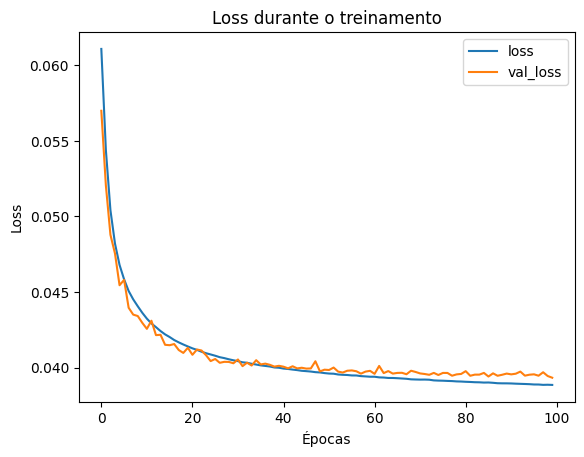

In [19]:
# Visualização de loss
import matplotlib.pyplot as plt

plt.plot(train_hist, label='loss')
plt.plot(valid_hist, label='val_loss')
plt.title('Loss durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

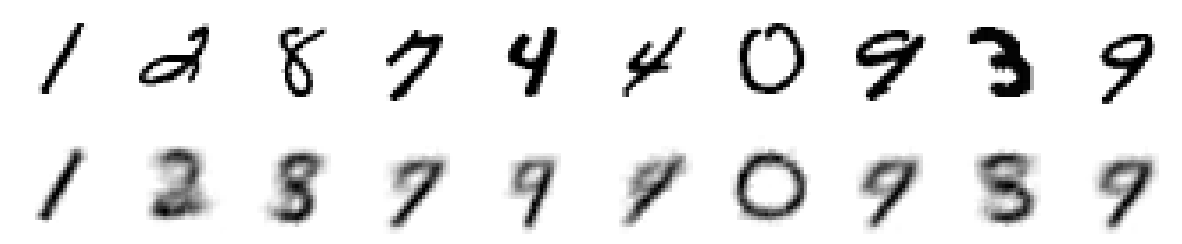

In [16]:
# Visualização de reconstruções
plot_reconstructions(conv_ae, X_valid.float(), n_images=10, apply_clip=True)   # mostra amostras

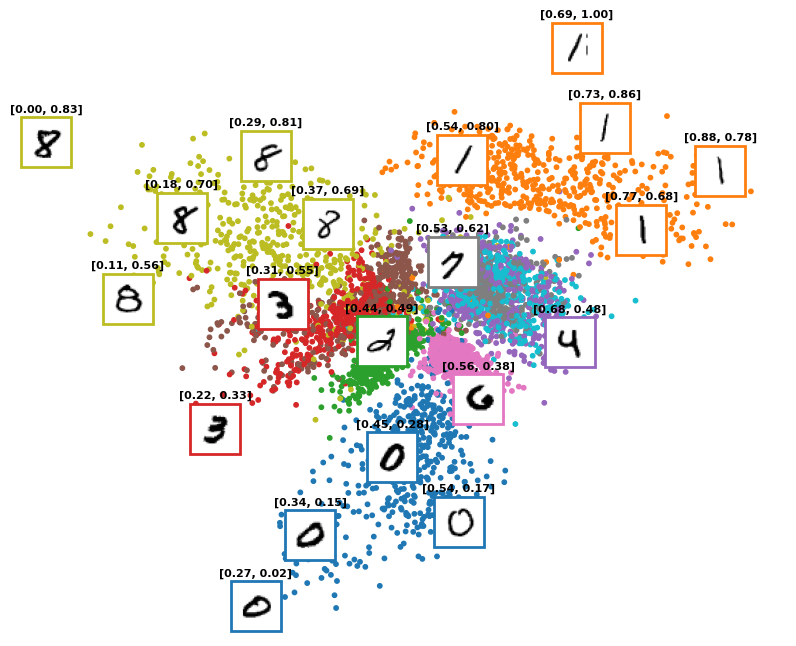

In [17]:
plot_latent_space_2d(conv_ae, X_valid, y_valid, batch_size=256, device=device)

# Autoencoders profundos de remoção de ruído

## Rede Neural

In [ ]:
# Encoder com dropout
class DropoutEncoder(nn.Module):
    def __init__(self, p=0.5):              # construtor com probabilidade
        super().__init__()                  # base
        self.net = nn.Sequential(           # sequência de camadas
            nn.Flatten(),
            nn.Dropout(p=p),
            nn.Linear(28*28, 100),
            nn.ReLU(),
            nn.Linear(100, Z_DIM_DENOISING_AE),
            nn.ReLU())
    def forward(self, x):                   # forward
        return self.net(x)                  # retorna código

# Decoder denso
class DropoutDecoder(nn.Module):
    def __init__(self):                     # construtor
        super().__init__()                  # base
        self.net = nn.Sequential(           # sequência de camadas
            nn.Linear(Z_DIM_DENOISING_AE, 100),
            nn.ReLU(),
            nn.Linear(100, 28*28),
        )
    def forward(self, z):                   # forward
        x = self.net(z)                     # aplica camadas
        x = x.view(-1, 28, 28)              # reshape para imagem
        return x                            # retorna reconstrução

# Denoising AE
class DropoutAE(nn.Module):
    def __init__(self, p=0.5):              # construtor
        super().__init__()                  # base
        self.encoder = DropoutEncoder(p=p)  # instancia encoder
        self.decoder = DropoutDecoder()     # instancia decoder
    def forward(self, x):                   # forward
        z = self.encoder(x)                 # codifica
        x_hat = self.decoder(z)             # decodifica
        return x_hat, z                     # retorna reconstrução e código

dropout_ae = DropoutAE(p=0.5).to(device)  # instancia AE com dropout 0.5

In [ ]:
# Inspecionar
summary(dropout_ae, input_size=(1, 1, 28, 28), col_names=("input_size", "output_size", "num_params"))  # mostra resumo do AE conv

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DropoutAE                                [1, 1, 28, 28]            [1, 28, 28]               --
├─DropoutEncoder: 1-1                    [1, 1, 28, 28]            [1, 30]                   --
│    └─Sequential: 2-1                   [1, 1, 28, 28]            [1, 30]                   --
│    │    └─Flatten: 3-1                 [1, 1, 28, 28]            [1, 784]                  --
│    │    └─Dropout: 3-2                 [1, 784]                  [1, 784]                  --
│    │    └─Linear: 3-3                  [1, 784]                  [1, 100]                  78,500
│    │    └─ReLU: 3-4                    [1, 100]                  [1, 100]                  --
│    │    └─Linear: 3-5                  [1, 100]                  [1, 30]                   3,030
│    │    └─ReLU: 3-6                    [1, 30]                   [1, 30]                   --
├─DropoutDecoder: 1-2       

In [ ]:
# Inspecionar
summary(dropout_ae.encoder, input_size=(1, 1, 28, 28), col_names=("input_size", "output_size", "num_params"))  # mostra resumo do encoder conv

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DropoutEncoder                           [1, 1, 28, 28]            [1, 30]                   --
├─Sequential: 1-1                        [1, 1, 28, 28]            [1, 30]                   --
│    └─Flatten: 2-1                      [1, 1, 28, 28]            [1, 784]                  --
│    └─Dropout: 2-2                      [1, 784]                  [1, 784]                  --
│    └─Linear: 2-3                       [1, 784]                  [1, 100]                  78,500
│    └─ReLU: 2-4                         [1, 100]                  [1, 100]                  --
│    └─Linear: 2-5                       [1, 100]                  [1, 30]                   3,030
│    └─ReLU: 2-6                         [1, 30]                   [1, 30]                   --
Total params: 81,530
Trainable params: 81,530
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.08
Input size (MB

In [ ]:
# Inspecionar
summary(dropout_ae.decoder, input_size=(1, Z_DIM_DENOISING_AE), col_names=("input_size", "output_size", "num_params"))  # mostra resumo do decoder conv

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DropoutDecoder                           [1, 30]                   [1, 28, 28]               --
├─Sequential: 1-1                        [1, 30]                   [1, 784]                  --
│    └─Linear: 2-1                       [1, 30]                   [1, 100]                  3,100
│    └─ReLU: 2-2                         [1, 100]                  [1, 100]                  --
│    └─Linear: 2-3                       [1, 100]                  [1, 784]                  79,184
Total params: 82,284
Trainable params: 82,284
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.08
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.33
Estimated Total Size (MB): 0.34

## Treinamento

In [ ]:
criterion = nn.MSELoss()                                    # define perda MSE
optimizer = optim.NAdam(dropout_ae.parameters(), lr=0.002)  # define otimizador

In [ ]:
train_hist, valid_hist = treinar_ae(dropout_ae, train_dl, valid_dl, optimizer, criterion, epochs=N_EPOCHS, device=device)

Época:   0%|                                                                | 0/100 [00:00<?, ?it/s]

## Visualizações

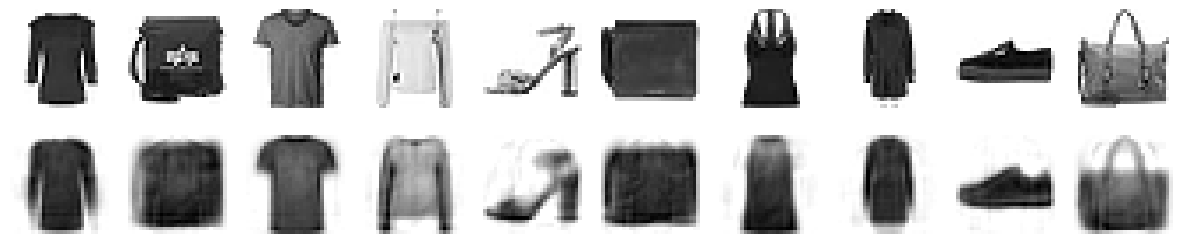

In [ ]:
# Visualização de reconstruções: reconstruções com dropout ativo (ruído)
dropout_ae.train()                                                              # ativa dropout para simular ruído
plot_reconstructions(dropout_ae, X_valid.float(), n_images=10, apply_clip=True) # mostra amostras

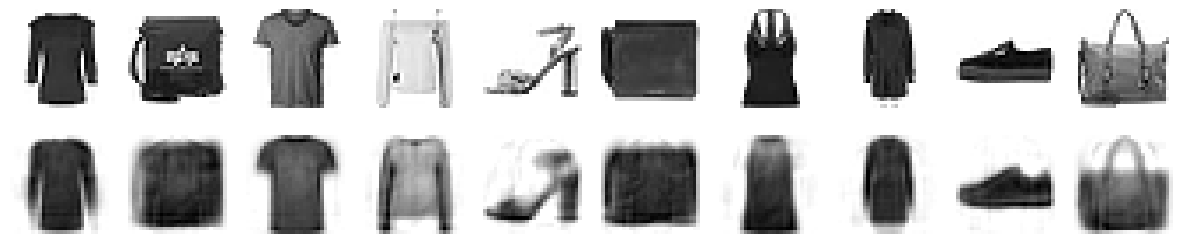

In [ ]:
# Visualização de reconstruções: reconstruções sem dropout (limpas)
dropout_ae.eval()                                                               # desativa dropout
plot_reconstructions(dropout_ae, X_valid.float(), n_images=10, apply_clip=True) # mostra amostras

# Autoencoder Esparso

## Rede Neural

In [ ]:
# Encoder esparso
class SparseEncoder(nn.Module):
    def __init__(self):             # construtor
        super().__init__()          # base
        self.net = nn.Sequential(   # sequência
            nn.Flatten(),
            nn.Linear(28*28, 100),
            nn.ReLU(),
            nn.Linear(100, Z_DIM_SPARSE_AE),
            nn.Sigmoid(),
        )
    def forward(self, x):           # forward
        return self.net(x)          # retorna código

# Decoder esparso
class SparseDecoder(nn.Module):
    def __init__(self):             # construtor
        super().__init__()          # base
        self.net = nn.Sequential(   # sequência
            nn.Linear(Z_DIM_SPARSE_AE, 100),
            nn.ReLU(),
            nn.Linear(100, 28*28),
        )
    def forward(self, z):           # forward
        x = self.net(z)             # aplica camadas
        x = x.view(-1, 28, 28)      # reshape para imagem
        return x                    # retorna reconstrução

# AE esparso
class SparseAE(nn.Module):
    def __init__(self):                 # construtor
        super().__init__()              # base
        self.encoder = SparseEncoder()  # instancia encoder
        self.decoder = SparseDecoder()  # instancia decoder
    def forward(self, x):               # forward
        z = self.encoder(x)             # codifica
        x_hat = self.decoder(z)         # decodifica
        return x_hat, z                 # retorna reconstrução e código

sparse_ae = SparseAE().to(device)  # instancia AE esparso

## Treinamento

In [ ]:
criterion = nn.MSELoss()                                    # define perda MSE
optimizer = optim.NAdam(sparse_ae.parameters(), lr=0.002)   # define otimizador

In [ ]:
train_hist, valid_hist = treinar_ae(sparse_ae, train_dl, valid_dl, optimizer, criterion, epochs=N_EPOCHS, device=device, l1_regularization=True, lambda_l1=1e-4)

Época:   0%|                                                                | 0/100 [00:00<?, ?it/s]

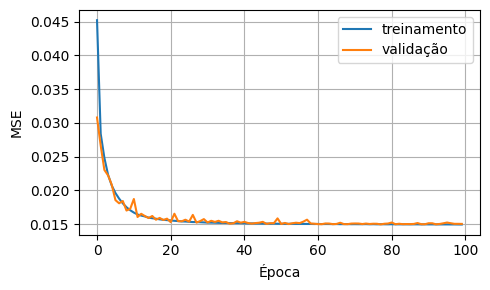

In [ ]:
curvas_de_treinamento(train_hist, valid_hist)

## Visualizações

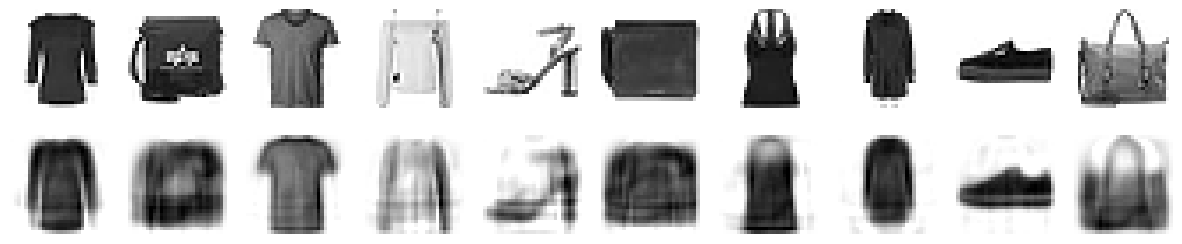

In [ ]:
# Visualização de reconstruções
plot_reconstructions(sparse_ae, X_valid.float(), n_images=10, apply_clip=True)   # mostra amostras